Title: Data Wrangling II 

Create an “Academic performance” dataset of students and perform the following operations using Python. 
1. Scan all variables for missing values and inconsistencies. If there are missing values and/or 
inconsistencies, use any of the suitable techniques to deal with them. 
2. Scan all numeric variables for outliers. If there are outliers, use any of the suitable techniques to deal with 
them. 
3. Apply data transformations on at least one of the variables. The purpose of this transformation should be 
one of the following reasons: to change the scale for better understanding of the variable, to convert a non- 
linear relation into a linear one, or to decrease the skewness and convert the distribution into a normal 
distribution. 

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

### 1. Create Dataset

In [2]:
np.random.seed(42)
data = {
    'Student_ID': range(1, 101),
    'Math_Score': np.random.normal(70, 15, 100),
    'Reading_Score': np.random.normal(75, 12, 100),
    'Absences': np.random.exponential(5, 100) # Purposely For Creating Right Skewed Data
}
df = pd.DataFrame(data)

df.loc[5:10, 'Math_Score'] = np.nan #Adding Missing Values 
df.loc[20, 'Math_Score'] = -50  # Adding Inconsistency
df.loc[50, 'Reading_Score'] = 200  #Adding Outliers

df.head(20)

,Student_ID,Math_Score,Reading_Score,Absences
0,1,77.450712,58.015551,10.493043
1,2,67.926035,69.952256,6.750171
2,3,79.715328,70.887426,5.970372
3,4,92.845448,65.372673,6.061438
4,5,66.487699,73.064571,2.227462
5,6,NaN,79.848610,1.737810
6,7,NaN,97.634231,8.286873
7,8,NaN,77.094934,8.306641
8,9,NaN,78.090605,10.089750
9,10,NaN,74.106649,12.223080


### 2. Scan for Missing Values

In [3]:
print("Missing values initially:\n", df.isnull().sum())

Missing values initially:
 Student_ID       0
Math_Score       6
Reading_Score    0
Absences         0
dtype: int64


### 3. Handle Inconsistencies

In [4]:
df.loc[df['Math_Score'] < 0, 'Math_Score'] = np.nan
print("Missing values after removing inconsistencies:\n", df.isnull().sum())

Missing values after removing inconsistencies:
 Student_ID       0
Math_Score       7
Reading_Score    0
Absences         0
dtype: int64


### 4. Impute Missing Values

In [5]:
df['Math_Score'] = df['Math_Score'].fillna(df['Math_Score'].median())
print("Missing values after imputation:\n", df.isnull().sum())

Missing values after imputation:
 Student_ID       0
Math_Score       0
Reading_Score    0
Absences         0
dtype: int64


### 5. Scan for Outliers

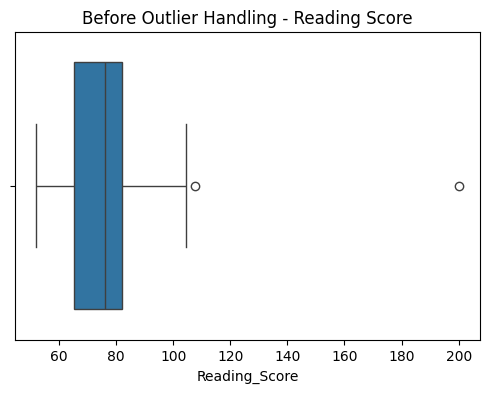

In [6]:
plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Reading_Score'])
plt.title('Before Outlier Handling - Reading Score')
plt.show()

### 6. Handle Outliers

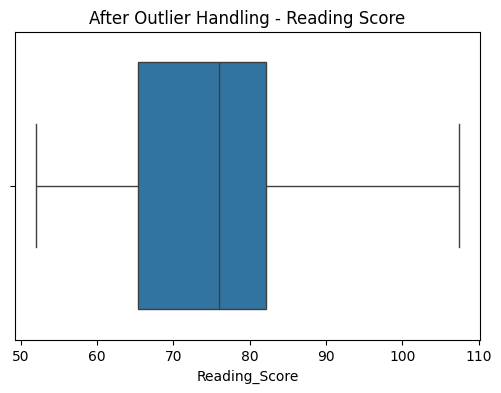

In [7]:
Q1 = df['Reading_Score'].quantile(0.25)
Q3 = df['Reading_Score'].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df['Reading_Score'] = np.clip(df['Reading_Score'], lower_bound, upper_bound)

plt.figure(figsize=(6, 4))
sns.boxplot(x=df['Reading_Score'])
plt.title('After Outlier Handling - Reading Score')
plt.show()

### 7. Analyze Skewed Variables

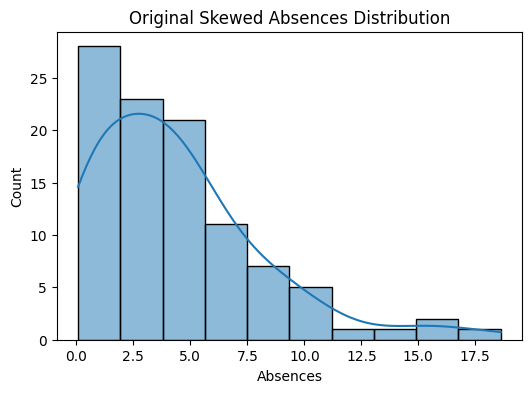

In [8]:
plt.figure(figsize=(6,4))
sns.histplot(df['Absences'], kde=True)
plt.title('Original Skewed Absences Distribution')
plt.show()

### 8. Apply Data Transformation

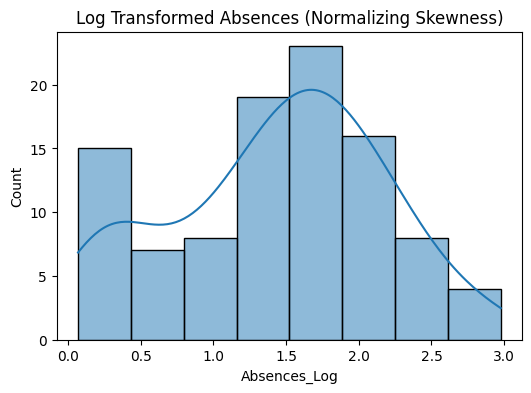

In [9]:
df['Absences_Log'] = np.log1p(df['Absences'])

plt.figure(figsize=(6,4))
sns.histplot(df['Absences_Log'], kde=True)
plt.title('Log Transformed Absences (Normalizing Skewness)')
plt.show()